# Conditional Graph


In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    operation:str
    operands:List[int]
    result:str

In [7]:
def adder(state:AgentState)->AgentState:
    """
    This node is to sum the operands
    """

    state['result'] = str(sum(state['operands']))

    return state


def mul_node(state:AgentState)->AgentState:
    """
    This node multiplies the numbers in the list
    """

    result = 1
    for x in state['operands']:
        result *= x

    state['result'] = str(result)

    return state


def decide_next_node(state:AgentState)->str:
    """
    This node will select the next node of the graph
    """

    if state['operation'] == "+":
        return "addition_operation"
    elif state['operation'] == "*":
        return "multiplication_operation"
    else:
        return END



In [9]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("mul_node", mul_node)
graph.add_node("router_node", lambda state:state)

graph.add_edge(START, "router_node")

graph.add_conditional_edges(
    "router_node",
    decide_next_node,
    {
        "addition_operation":"add_node",
        "multiplication_operation":"mul_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("mul_node", END)

In [10]:
app = graph.compile()

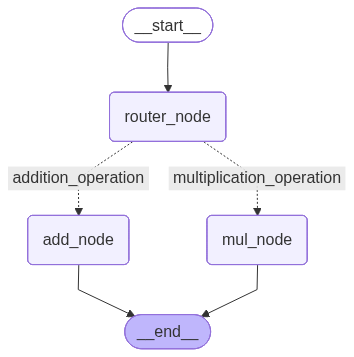

In [11]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
result = app.invoke({"operation":"+", "operands":[5,8]})
result

{'operation': '+', 'operands': [5, 8], 'result': '13'}